# TropiCycloneNet — Startoff Notebook

This notebook supports you to start off with the **TropiCycloneNet Dataset (TCN_D)**.

It helps you:
1. download either the **test subset** or the **full dataset**
2. inspect the structure of **Data_1d, Data_3d, and Env-Data**
3. make **clean scientific tropical cyclone visualizations**
4. directions to work on with

---
## What this dataset is

TropiCycloneNet is a multimodal tropical cyclone dataset covering **1950–2023** across six major ocean basins. It contains:
- `Data_1d`: cyclone-center attributes such as longitude, latitude, pressure, wind
- `Data_3d`: gridded meteorological fields around the cyclone center
- `Env-Data`: structured environmental features

The official dataset page describes:
- full dataset: about **25.7 GB**
- test subset: about **3.34 GB**
- `Data_3d` covers a **20° × 20°** region centered on the storm
- spatial resolution: **0.25°**
- temporal resolution: **6-hourly**

## 0. Import packages

In [12]:
# Optional installs
# !pip install -q gdown netCDF4 pandas numpy matplotlib cartopy seaborn xarray scipy

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

DATA_DIR = Path("data/tropicyclonenet")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Official download options
The official dataset repository provides:
- **Full dataset** (~25.7 GB)
- **Test subset** (~3.34 GB)

The GitHub documentation also provides a `read_TCND.py` script to visualize examples.

### recommendation
Start with the **test subset**. It is much more realistic for classroom work.

In [13]:
# Google Drive file IDs from the official dataset page
GDRIVE_IDS = {
    "full_dataset": "1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT",
    "test_subset": "1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi",
}
GDRIVE_IDS

{'full_dataset': '1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT',
 'test_subset': '1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi'}

Run the below cell to get the ready to copy command for download the dataset !

In [14]:
def gdown_command(file_id, output_name):
    return f"gdown --fuzzy 'https://drive.google.com/file/d/{file_id}/view?usp=sharing' -O {output_name}"

print("Test subset:")
print(gdown_command(GDRIVE_IDS["test_subset"], DATA_DIR / "TCND_test.zip"))
print("\nFull dataset:")
print(gdown_command(GDRIVE_IDS["full_dataset"], DATA_DIR / "TCND_full.zip"))

Test subset:
gdown --fuzzy 'https://drive.google.com/file/d/1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi/view?usp=sharing' -O data/tropicyclonenet/TCND_test.zip

Full dataset:
gdown --fuzzy 'https://drive.google.com/file/d/1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT/view?usp=sharing' -O data/tropicyclonenet/TCND_full.zip



### Install gdown if needed
pip install gdown

### Download the test subset
gdown --fuzzy "https://drive.google.com/file/d/1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi/view?usp=sharing" -O data/tropicyclonenet/TCND_test.zip

### Download the full dataset
gdown --fuzzy "https://drive.google.com/file/d/1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT/view?usp=sharing" -O data/tropicyclonenet/TCND_full.zip


## 2. Inspect folder structure

After extraction, first inspect whether the archive contains:
- `Data_1d/`
- `Data_3d/`
- `Env-Data/`

That immediately tells students how multimodality is organized.

In [15]:
import zipfile

def unzip_file(zip_path, extract_dir=None):
    zip_path = Path(zip_path)
    if extract_dir is None:
        extract_dir = zip_path.with_suffix("")
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print(f"Extracted to {extract_dir}")
    return extract_dir

def print_tree(root, max_depth=2, prefix=""):
    root = Path(root)
    if not root.exists():
        print(f"Missing path: {root}")
        return
    for p in sorted(root.iterdir()):
        print(prefix + p.name + ("/" if p.is_dir() else ""))
        if p.is_dir() and max_depth > 0:
            print_tree(p, max_depth=max_depth-1, prefix=prefix + "    ")

# Example:
# unzip_file(DATA_DIR / "TCND_test.zip", DATA_DIR / "TCND_test")
# print_tree(DATA_DIR / "TCND_test", max_depth=2)

In [16]:
def scan_files(root):
    root = Path(root)
    rows = []
    for p in root.rglob("*"):
        if p.is_file():
            rows.append({
                "path": str(p),
                "suffix": p.suffix.lower(),
                "size_mb": round(p.stat().st_size / 1024**2, 3)
            })
    return pd.DataFrame(rows).sort_values(["suffix", "path"]).reset_index(drop=True)

# Example:
# files_df = scan_files(DATA_DIR / "TCND_test")
# files_df.head(100)

## 3. Reading patterns

The official docs suggest using `read_TCND.py` with:
`python read_TCND.py dataset_path TC_name TC_date area train_val_test`

For simple loading as startoff, it is useful to add a more explicit inspection workflow:
- identify tabular files in `Data_1d`
- identify gridded files in `Data_3d`
- inspect environmental feature files in `Env-Data`

In [17]:
def preview_tabular(path, n=5):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, nrows=n)
    elif path.suffix.lower() in [".txt"]:
        return pd.read_csv(path, sep=None, engine="python", nrows=n)
    elif path.suffix.lower() in [".parquet"]:
        return pd.read_parquet(path).head(n)
    else:
        raise ValueError(f"Unsupported tabular preview: {path.suffix}")

In [18]:
def guess_tc_columns(df):
    rename = {}
    for c in df.columns:
        low = c.lower()
        if low in ["lat", "latitude"]:
            rename[c] = "latitude"
        elif low in ["lon", "longitude", "long"]:
            rename[c] = "longitude"
        elif "wind" in low:
            rename[c] = "wind"
        elif "press" in low:
            rename[c] = "pressure"
        elif "time" in low or "date" in low:
            rename[c] = "time"
        elif "name" in low:
            rename[c] = "tc_name"
    return df.rename(columns=rename)

## 4. Scientific visualization helpers

These are tailored to cyclone data:
- track maps
- intensity-time plots
- basin summaries
- storm-centered field plots

In [19]:
def plot_track(df, title="Tropical cyclone track", basin=None):
    df = guess_tc_columns(df.copy())
    if basin is not None and "basin" in df.columns:
        df = df[df["basin"] == basin]
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time")

    if HAS_CARTOPY:
        fig = plt.figure(figsize=(10,5))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
        ax.plot(df["longitude"], df["latitude"], "-o", ms=3, transform=ccrs.PlateCarree())
        ax.set_title(title, weight="bold")
    else:
        fig, ax = plt.subplots(figsize=(10,5))
        ax.plot(df["longitude"], df["latitude"], "-o", ms=3)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(title, weight="bold")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def plot_intensity_time(df, wind_col="wind", pressure_col="pressure"):
    df = guess_tc_columns(df.copy())
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time")

    fig, ax1 = plt.subplots(figsize=(11,4))
    if wind_col in df.columns:
        ax1.plot(df["time"], df[wind_col], label="Wind")
        ax1.set_ylabel("Wind")
    if pressure_col in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df["time"], df[pressure_col], "--", label="Pressure")
        ax2.set_ylabel("Pressure")
    ax1.set_title("Storm intensity evolution", weight="bold")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def plot_basin_counts(df, basin_col="basin"):
    fig, ax = plt.subplots(figsize=(7,4))
    df[basin_col].value_counts().sort_values(ascending=False).plot.bar(ax=ax)
    ax.set_title("Cyclone counts by basin", weight="bold")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    return fig

## 5. Example storm-centered grid visualization

The official description says `Data_3d` includes:
- geopotential height (you can learn more about geopotential height [here](https://www.weather.gov/source/zhu/ZHU_Training_Page/Miscellaneous/Heights_Thicknesses/thickness_temperature.htm#GEOPOTENTIAL))
- U and V wind components
- pressure levels 200, 500, 850, 925 hPa 
- SST

If your `Data_3d` files are NetCDF-like, the template below is a good starting point.

Dataset Variables:
 ['u', 'v', 'z', 'sst']
Coordinates:
 ['time', 'pressure_level', 'latitude', 'longitude']


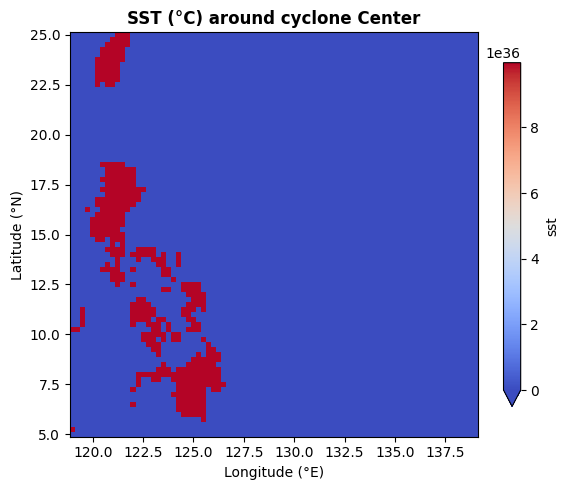

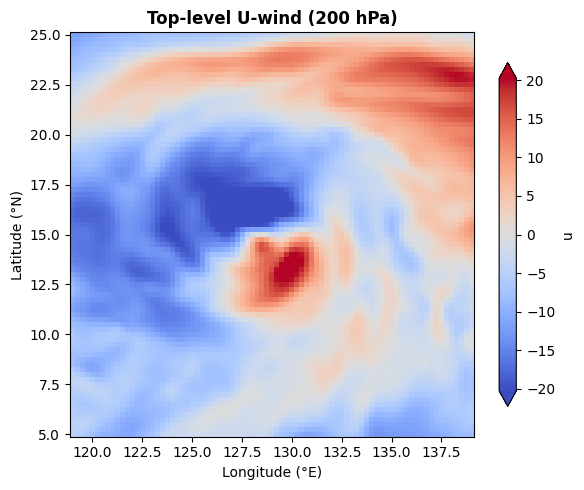

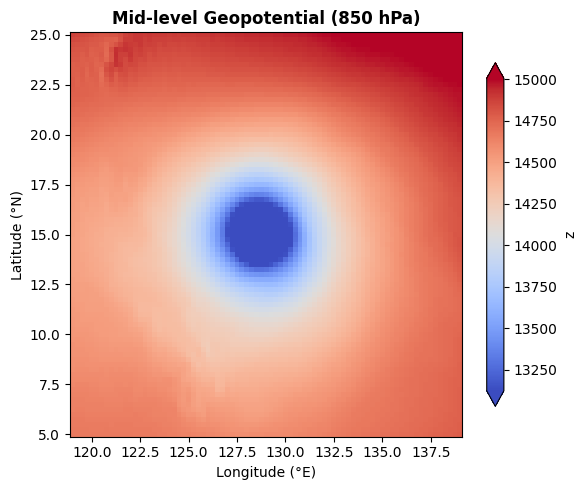

In [22]:
try:
    import xarray as xr
except Exception:
    xr = None

def plot_storm_field(da, title=None, cmap="coolwarm", figsize=(6,5)):
    fig, ax = plt.subplots(figsize=figsize)
    da.plot(ax=ax, cmap=cmap, robust=True, cbar_kwargs={"shrink":0.85})
    ax.set_title(title or str(da.name), weight="bold")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    plt.tight_layout()
    return fig

# Let's inspect an actual file as an example
nc_file = "data/tropicyclonenet/TCND_test/Data3D/WP/2018/MANGKHUT/TCND_MANGKHUT_2018091312_sst_z_u_v.nc"
if xr is not None and Path(nc_file).exists():
    ds3d = xr.open_dataset(nc_file)
    print("Dataset Variables:\n", list(ds3d.data_vars))
    print("Coordinates:\n", list(ds3d.coords))
    
    # 1) SST has only spatial dimensions (latitude, longitude) and no 'time'
    fig_sst = plot_storm_field(ds3d["sst"], "SST (°C) around cyclone Center")
    
    # 2) U, V, Z have dimensions (time, pressure_level, latitude, longitude)
    # Select the first time slice, and pressure_level=0 (e.g. 200 hPa level)
    fig_u = plot_storm_field(ds3d["u"].isel(time=0, pressure_level=0), "Top-level U-wind (200 hPa)")
    
    # Select pressure_level=2 (e.g. 850 hPa level)
    fig_z = plot_storm_field(ds3d["z"].isel(time=0, pressure_level=2), "Mid-level Geopotential (850 hPa)")
else:
    print("No NetCDF files found ")


## 6. Suggested project directions

### A — Track forecasting vs intensity forecasting
One may argue whether the same input modalities help both tasks equally, or whether track and intensity need different information.

### B — Basin generalization
Train on one basin or a subset of basins, then test transfer to another basin:
- Atlantic → Western Pacific
- Western Pacific → Indian Ocean

### C — Environmental precursors of rapid intensification
Use `Env-Data` and `Data_3d` to study which and how environmental conditions precede sharp increases in wind speed. You can even predict the next state, intensity growth or the timing of the next sharp increase.

### D — Multimodal fusion ablation
Compare:
- `Data_1d` only
- `Data_3d` only
- `Env-Data` only
- fused models

## 7. extra notes / comments

TropiCycloneNet is scientifically engaging, especially for the interest in hazards and extremes.

It works very well if you want **extreme-event, multimodal, time series, and spatiotemporal** projects.

## 8. Generate and Display GIF Animation

The following code creates a GIF animation across time steps for the MANGKHUT cyclone using the `Data_3d` NetCDF files, similar to the tracking animations seen on the project's repository. We will compute the wind speed at 850 hPa (mid-level) from the `u` and `v` components and plot it frame-by-frame.

In [23]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, Image, HTML

def create_tc_animation(data_dir, output_gif="tc_animation.gif", fps=10):
    nc_files = sorted(glob.glob(f"{data_dir}/*.nc"))
    if not nc_files:
        print(f"No .nc files found in {data_dir}")
        return None
    
    print(f"Found {len(nc_files)} files. Generating animation...")
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Initialize first frame
    ds = xr.open_dataset(nc_files[0])
    # Try calculating wind speed at 850 hPa (index 2 for pressure_level)
    u_val = ds["u"].isel(time=0, pressure_level=2).values
    v_val = ds["v"].isel(time=0, pressure_level=2).values
    wind_spd = np.sqrt(u_val**2 + v_val**2)

    img = ax.imshow(wind_spd, cmap="viridis", origin="lower")
    plt.colorbar(img, ax=ax, label="Wind speed (m/s)")
    ax.set_xlabel("Longitude index")
    ax.set_ylabel("Latitude index")

    # Adding text for the timestamp
    title_text = ax.set_title("", weight="bold")
    
    def animate(i):
        ds_frame = xr.open_dataset(nc_files[i])
        u_f = ds_frame["u"].isel(time=0, pressure_level=2).values
        v_f = ds_frame["v"].isel(time=0, pressure_level=2).values
        wind_spd_f = np.sqrt(u_f**2 + v_f**2)
        img.set_array(wind_spd_f)
        
        # Extract Datetime from filename
        fname = os.path.basename(nc_files[i])
        date_str = fname.split('_')[2] # E.g., 2018091312
        title_text.set_text(f"Wind Speed (850 hPa) - {date_str[:8]} {date_str[8:]}:00")
        
        ds_frame.close()
        return [img, title_text]
    
    anim = animation.FuncAnimation(fig, animate, frames=len(nc_files), interval=1000/fps, blit=True)
    anim.save(output_gif, writer="pillow", fps=fps)
    plt.close(fig) # Prevent duplicate static plot in output
    print(f"Saved {output_gif}")
    
    return output_gif

# Directory for MANGKHUT
mangkhut_dir = "data/tropicyclonenet/TCND_test/Data3D/WP/2018/MANGKHUT"
gif_path = create_tc_animation(mangkhut_dir, "mangkhut_anim.gif", fps=8)

if gif_path:
    # Display the GIF inside the notebook
    display(HTML(f'<img src="{gif_path}" style="width:600px; height:auto;" />'))

Found 43 files. Generating animation...
Saved mangkhut_anim.gif


## 9. Tracking the Cyclone over a Map

While generating an animation frame by frame is nice, tracing the track on a geographical map is much more insightful, similar to how true satellite tracking looks. We can use `Cartopy` to plot the coastlines and overlay the wind speed patch at the exact location along with its path!

In [24]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML

# Only run if Cartopy is available
if HAS_CARTOPY:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    def create_mapped_tc_animation(data_dir, output_gif="tc_mapped_animation.gif", fps=7):
        nc_files = sorted(glob.glob(f"{data_dir}/*.nc"))
        if not nc_files: return None
        
        # 1. Compute bounds
        lons, lats, tc_lons, tc_lats = [], [], [], []
        for f in nc_files:
            with xr.open_dataset(f) as ds:
                lons.extend([ds['longitude'].min().values, ds['longitude'].max().values])
                lats.extend([ds['latitude'].min().values, ds['latitude'].max().values])
                
                # Center index is the storm's exact location
                tc_lon = ds['longitude'][len(ds['longitude']) // 2].values
                tc_lat = ds['latitude'][len(ds['latitude']) // 2].values
                tc_lons.append(tc_lon)
                tc_lats.append(tc_lat)

        extent = [min(lons)-2, max(lons)+2, min(lats)-2, max(lats)+2]
        
        # 2. Setup Aesthetic Base Plot
        plt.style.use('dark_background') # Give it a sleek dark theme
        fig = plt.figure(figsize=(10, 6), dpi=120)
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Apply strict professional aesthetic background
        ax.set_facecolor('#112233') # Ocean
        land_feature = cfeature.NaturalEarthFeature(category='physical', name='land', scale='50m', facecolor='#223344')
        ax.add_feature(land_feature, zorder=1)
        ax.coastlines(linewidth=0.8, color='#556677', zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#556677', zorder=2)
        
        # Semi-transparent gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3, color='white', linestyle='--', zorder=3)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'color': 'lightgray', 'size': 9}
        gl.ylabel_style = {'color': 'lightgray', 'size': 9}
        
        # Title box
        title_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color='white', 
                             fontsize=12, weight='bold', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'), zorder=10)
        
        # Dynamic track line with glowing scatter
        track_line, = ax.plot([], [], '-', color='cyan', linewidth=2, alpha=0.8, transform=ccrs.PlateCarree(), zorder=5)
        track_points = ax.scatter([], [], s=30, color='white', edgecolors='cyan', zorder=6, transform=ccrs.PlateCarree())
        current_point = ax.scatter([], [], s=80, color='red', edgecolors='white', zorder=7, transform=ccrs.PlateCarree())
        
        # Set up a dummy pcolormesh specifically to generate ONE neat horizontal colorbar
        dummy_z = np.zeros((2, 2))
        dummy_lons = np.array([[extent[0], extent[1]], [extent[0], extent[1]]])
        dummy_lats = np.array([[extent[2], extent[2]], [extent[3], extent[3]]])
        dummy_mesh = ax.pcolormesh(dummy_lons, dummy_lats, dummy_z, cmap="magma", 
                                   vmin=0, vmax=50, transform=ccrs.PlateCarree(), visible=False, zorder=0)
        
        # Add a sleek, small horizontal colorbar at the bottom right
        cax = fig.add_axes([0.65, 0.15, 0.22, 0.02]) # [left, bottom, width, height]
        cbar = plt.colorbar(dummy_mesh, cax=cax, orientation='horizontal')
        cbar.set_label("Wind Speed (m/s)", color='white', size=10, weight='bold')
        cbar.ax.tick_params(colors='white', labelsize=9)
        cbar.outline.set_edgecolor('#556677')
        
        pmesh = [None]
        
        def animate(i):
            if pmesh[0] is not None:
                pmesh[0].remove()
                
            with xr.open_dataset(nc_files[i]) as ds_frame:
                u_f = ds_frame["u"].isel(time=0, pressure_level=2).values
                v_f = ds_frame["v"].isel(time=0, pressure_level=2).values
                w_spd_f = np.sqrt(u_f**2 + v_f**2)

                lon_f, lat_f = ds_frame['longitude'].values, ds_frame['latitude'].values
                lon_f_2d, lat_f_2d = np.meshgrid(lon_f, lat_f)
                
                # Plot the cyclone wind mesh using Magma glow
                pmesh[0] = ax.pcolormesh(lon_f_2d, lat_f_2d, w_spd_f, cmap="magma", 
                                         vmin=0, vmax=50, transform=ccrs.PlateCarree(), alpha=0.85, shading='gouraud', zorder=4)
                
                # Update tracing locations
                track_line.set_data(tc_lons[:i+1], tc_lats[:i+1])
                track_points.set_offsets(np.column_stack((tc_lons[:i+1], tc_lats[:i+1])))
                current_point.set_offsets(np.column_stack(([tc_lons[i]], [tc_lats[i]])))
                
                # Update timestamp overlay
                fname = os.path.basename(nc_files[i])
                date_str = fname.split('_')[2]
                time_formatted = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]} {date_str[8:]}:00 UTC"
                title_text.set_text(f"TC MANGKHUT (850hPa) | {time_formatted}")
                
            return [pmesh[0], track_line, track_points, current_point, title_text]
            
        anim = animation.FuncAnimation(fig, animate, frames=len(nc_files), interval=1000/fps, blit=False)
        anim.save(output_gif, writer="pillow", fps=fps)
        
        # Reset the Matplotlib plot style so it doesn't affect subsequent notebook plots globally
        plt.style.use('default')
        plt.close(fig)
        return output_gif

    mangkhut_dir = "data/tropicyclonenet/TCND_test/Data3D/WP/2018/MANGKHUT"
    print("Generating aesthetic geographic track animation...")
    mapped_gif = create_mapped_tc_animation(mangkhut_dir, "mangkhut_mapped_anim.gif", fps=7)
    
    if mapped_gif:
        display(HTML(f'<img src="{mapped_gif}?{np.random.randint(1000)}" style="width:800px; height:auto; box-shadow: 0 4px 8px 0 rgba(0,0,0,0.5); border-radius: 5px;" />'))
else:
    print("Cartopy is not installed. Please install it to run this visualization.")


Generating aesthetic geographic track animation...


/opt/anaconda3/envs/dev12/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/dev12/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/envs/dev12/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
